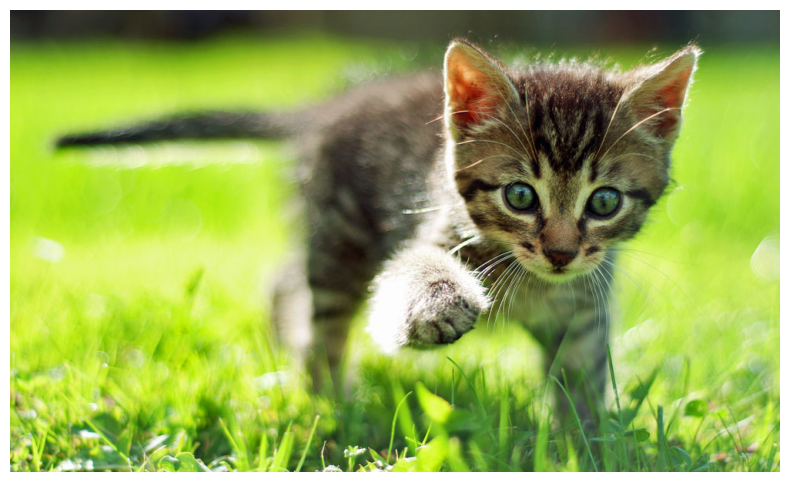

In [1]:
import requests
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO
import numpy as np


url = "https://nutrisourcepetfoods.com/wp-content/uploads/2020/03/shutterstock_67901620-1000x600sfw-1.jpg"

response = requests.get(url)

Im = Image.open(BytesIO(response.content))

plt.figure(figsize=(10, 6))
plt.imshow(Im)
plt.axis('off')
plt.show()

In [2]:
I = np.array(Im)
I = 0.2989 *I[:,:,0] + 0.5870 *I[:,:,1] + 0.1140*I[:,:,2]
I

array([[ 33.7085,  33.7085,  33.7085, ...,  75.3253,  75.0973,  75.0973],
       [ 33.7085,  33.7085,  33.7085, ...,  75.3253,  75.0973,  75.0973],
       [ 33.7085,  33.7085,  33.7085, ...,  76.3252,  76.0972,  75.0973],
       ...,
       [144.0194, 144.9437, 133.0452, ..., 171.9528, 179.2896, 172.617 ],
       [133.8956, 133.0912, 118.991 , ..., 170.235 , 182.1476, 174.2964],
       [168.1803, 138.0198, 114.8496, ..., 172.2718, 178.9892, 180.1263]])

In [3]:
I = I.astype(np.float32) / 255.0
I

array([[0.1321902 , 0.1321902 , 0.1321902 , ..., 0.29539335, 0.29449922,
        0.29449922],
       [0.1321902 , 0.1321902 , 0.1321902 , ..., 0.29539335, 0.29449922,
        0.29449922],
       [0.1321902 , 0.1321902 , 0.1321902 , ..., 0.29931453, 0.2984204 ,
        0.29449922],
       ...,
       [0.56478196, 0.56840664, 0.52174586, ..., 0.67432475, 0.70309645,
        0.6769294 ],
       [0.5250808 , 0.5219263 , 0.46663135, ..., 0.66758823, 0.7143043 ,
        0.6835153 ],
       [0.6595306 , 0.54125416, 0.4503906 , ..., 0.67557573, 0.7019184 ,
        0.7063776 ]], dtype=float32)

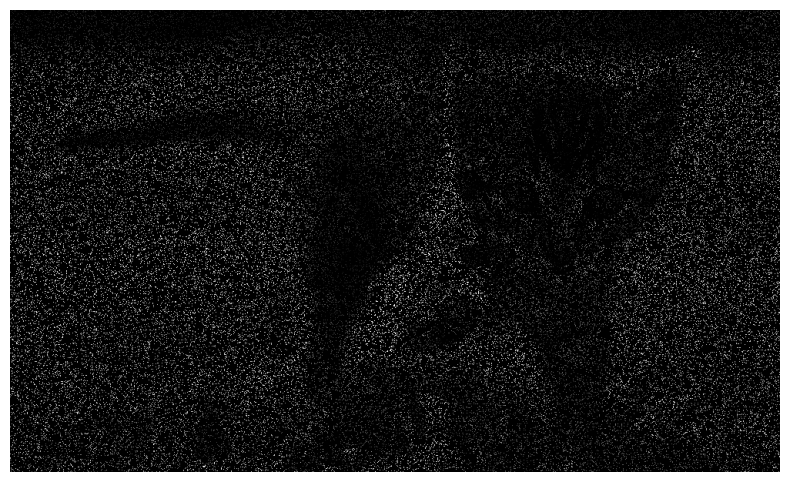

In [4]:
p = 0.1 # porcentaje de píxeles
mask_random = np.random.rand(*I.shape) < p
I_random = I * mask_random
plt.figure(figsize=(10, 6))
plt.imshow(I_random, cmap='gray')
plt.axis('off')
plt.show()

In [5]:
I.shape

(600, 1000)

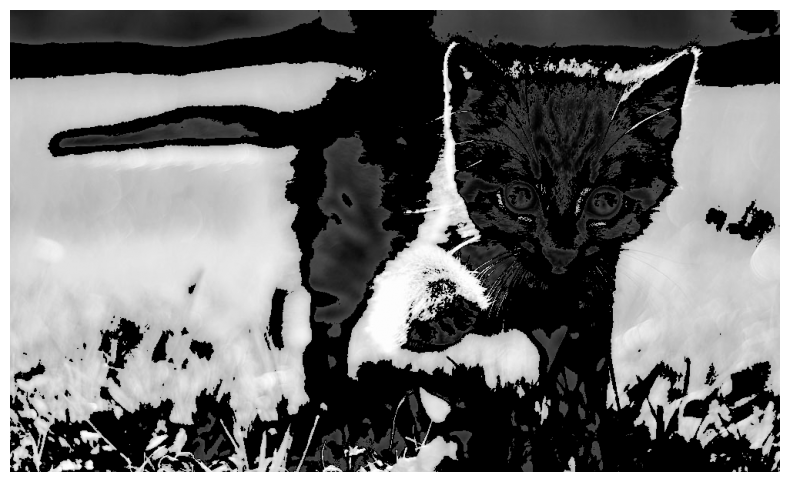

In [6]:
I = np.array(Im)
I = 0.2989 *I[:,:,0] + 0.5870 *I[:,:,1] + 0.1140*I[:,:,2]
I = I.astype(np.float32) / 255.0


threshold_low = 0.3
threshold_high = 0.7

mask_intensity = (I < threshold_low) | (I > threshold_high)
I_intensity = I * mask_intensity

plt.figure(figsize=(10, 6))
plt.imshow(I_intensity, cmap='gray')
plt.axis('off')
plt.show()

In [7]:
I = np.array(Im)
I = 0.2989 *I[:,:,0] + 0.5870 *I[:,:,1] + 0.1140*I[:,:,2]
I = I.astype(np.float32) / 255.0

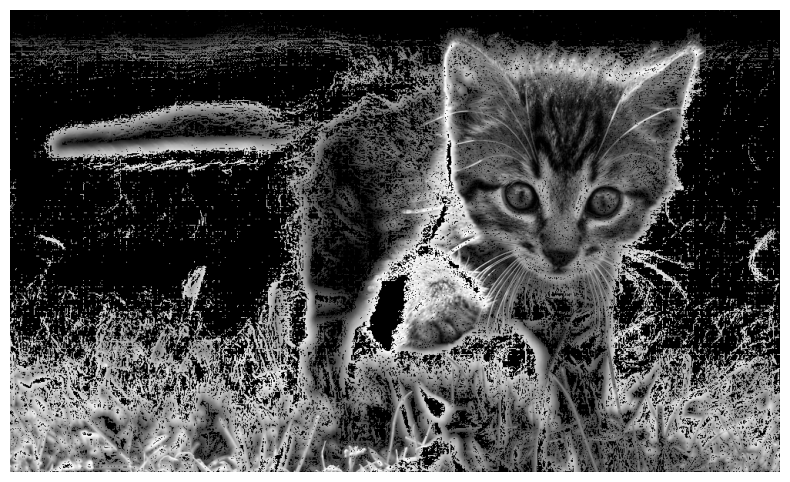

In [8]:
diff_x = np.abs(I[:, :-1] - I[:, 1:])
diff_y = np.abs(I[:-1, :] - I[1:, :])

score = np.zeros_like(I)
score[:, :-1] += diff_x
score[:-1, :] += diff_y

k = int(0.5 * I.size)
indices = np.argsort(score.flatten())[-k:]

mask_diff = np.zeros_like(I, dtype=bool)
mask_diff_flat = mask_diff.flatten()
mask_diff_flat[indices] = True
mask_diff = mask_diff_flat.reshape(I.shape)

I_diff = I * mask_diff


plt.figure(figsize=(10, 6))
plt.imshow(I_diff, cmap='gray')
plt.axis('off')
plt.show()